In [1]:
# Core
import re
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from adjustText import adjust_text
import seaborn as sns

# Load Dataset
df = pd.read_csv("D:/Data Analyst/project/Python_project_2/dataset/netflix_titles.csv")

# Parse date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month.astype('Int64')
df['month_name'] = df['date_added'].dt.strftime('%b')

# Extract duration values
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype('Int64')
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z])')

# Fill missing ratings with 'Unknown'
df['rating'] = df['rating'].fillna("Unknown")

# Primary country (some entries have multiple countries)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()

### Top 10 Content-Producing Countries

In [2]:
df_country = df['primary_country'].value_counts().head(10).to_frame()

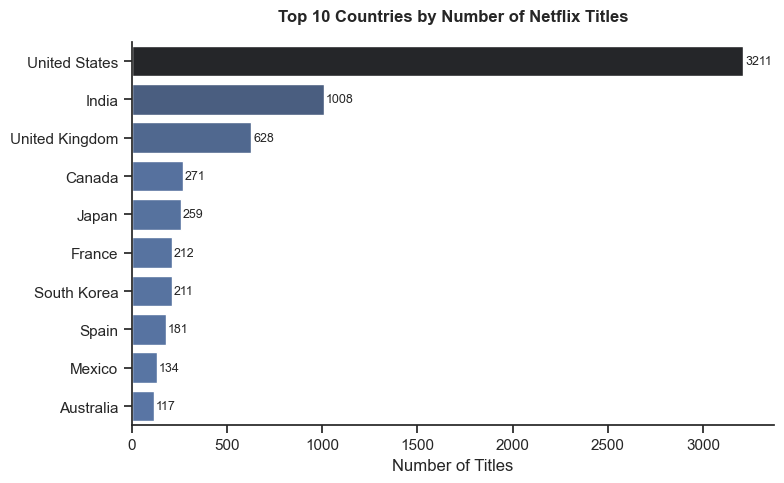

In [6]:
plt.figure(figsize=(8, 5))

sns.set_theme(style='ticks')
sns.barplot(
    data=df_country, 
    x='count', 
    y='primary_country',
    hue='count',
    palette='dark:b_r',
    legend=False
)
sns.despine()

plt.title('Top 10 Countries by Number of Netflix Titles', fontweight='bold', pad=15)
plt.xlabel('Number of Titles')
plt.ylabel('')

for i, value in enumerate(df_country['count']):
    plt.text(value+10, i, f'{value}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Country Split — Movies vs TV Shows (Top 10 Countries)

In [4]:
df.pivot_table(index='primary_country', columns='type', aggfunc='size', fill_value=0)

type,Movie,TV Show
primary_country,,
,1,1
Argentina,56,20
Australia,61,56
Austria,8,1
Bangladesh,3,0
...,...,...
Uruguay,8,1
Venezuela,2,0
Vietnam,7,0


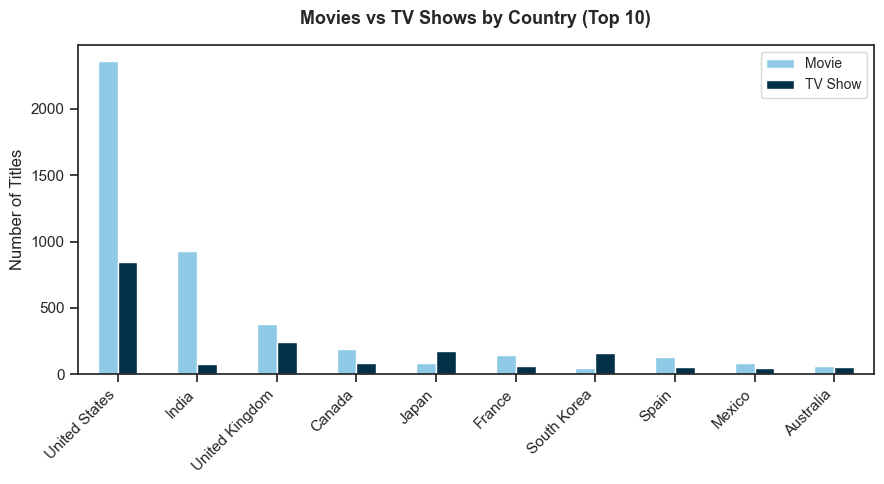

In [5]:
top_countries = df['primary_country'].value_counts().head(10).index

df_plot = df.pivot_table(index='primary_country', columns='type', aggfunc='size', fill_value=0)
df_plot = df_plot.loc[top_countries]

df_plot.plot(kind='bar', figsize=(9,5), color=['#8ECAE6', '#023047'])
plt.title('Movies vs TV Shows by Country (Top 10)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Number of Titles')
plt.xlabel('')
plt.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()